***

# 📖 深度学习权重初始化：Xavier 与 Kaiming (He) 方法的严密推导

在深度神经网络中，如果不加干预，前向传播中激活值的方差（信号强度）会逐层放大（**梯度爆炸**）或缩小（**梯度消失**）；反向传播中的梯度也会经历同样的过程。

初始化策略的终极物理意义，就是**让信息（方差）在网络的前向和反向流动中保持平稳**。

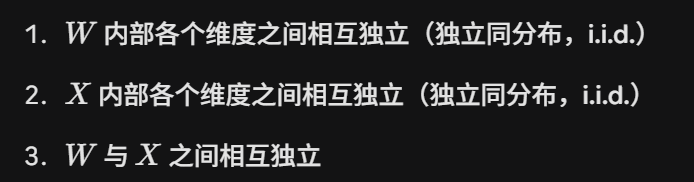

---

## 🛠️ 预备知识：概率论核心定理

在推导之前，必须明确三个贯穿始终的概率论公式。假设有两个相互独立的随机变量 $X$ 和 $Y$：

1. **独立变量相加的方差：**
   $$Var\left(\sum_{i=1}^{n} X_i\right) = \sum_{i=1}^{n} Var(X_i)$$
2. **期望为零的独立变量相乘的方差：** 若 $E[X]=0$ 且 $E[Y]=0$，则：
   $$Var(XY) = Var(X) \cdot Var(Y)$$
3. **方差与期望的基本关系：**
   $$Var(X) = E[X^2] - (E[X])^2$$
   特别地，当均值 $E[X]=0$ 时：
   $$Var(X) = E[X^2]$$

---

## 1️⃣ Xavier (Glorot) 初始化

> **提出年份:** 2010
> **最佳拍档:** `Tanh`, `Sigmoid` (在 $x=0$ 附近近似线性的激活函数)

### 1.1 基本假设
1. 权重 $W$ 独立同分布，且均值为 0，即 $E[W] = 0$。
2. 每一层的输入 $X$ 独立同分布，且均值为 0，即 $E[X] = 0$。
3. 激活函数 $f(x)$ 在 0 附近近似为恒等映射，即 $f(x) \approx x$（适用于 Tanh 等）。因此可以假设处于线性状态。

### 1.2 前向传播推导
假设第 $l$ 层全连接网络计算公式为：
$$y_i = \sum_{j=1}^{n_{in}} w_{ij} x_j$$
其中 $n_{in}$ 是输入神经元数量。计算输出 $y_i$ 的方差：
$$Var(y_i) = Var\left(\sum_{j=1}^{n_{in}} w_{ij} x_j\right) = \sum_{j=1}^{n_{in}} Var(w_{ij} x_j)$$
因为 $E[w]=0, E[x]=0$，根据预备定理 2 展开乘积的方差：
$$Var(y) = n_{in} \cdot Var(w) \cdot Var(x)$$

**🌟 目标：** 为了让信号方差不被放大或缩小，要求 $Var(y) = Var(x)$：
$$n_{in} \cdot Var(w) = 1 \implies Var(w) = \frac{1}{n_{in}}$$

### 1.3 反向传播推导
反向传播中，对输入 $x_j$ 的梯度为：
$$\frac{\partial L}{\partial x_j} = \sum_{i=1}^{n_{out}} w_{ij} \frac{\partial L}{\partial y_i}$$
同理，为了让梯度的方差在传播时保持不变，我们要求：
$$n_{out} \cdot Var(w) = 1 \implies Var(w) = \frac{1}{n_{out}}$$

### 1.4 最终折中方案
通常输入与输出维度不相等 ($n_{in} \neq n_{out}$)。Xavier 取两者的**调和平均数**作为最终的权重方差目标：
$$Var(W) = \frac{2}{n_{in} + n_{out}}$$

**PyTorch API:** `nn.init.xavier_normal_` 或 `nn.init.xavier_uniform_`

**分布参数：**
* **均匀分布 $U(-a, a)$：** 方差为 $\frac{a^2}{3}$，令其等于 $\frac{2}{n_{in} + n_{out}}$，解得 $a = \sqrt{\frac{6}{n_{in} + n_{out}}}$。
* **正态分布 $N(0, \sigma^2)$：** 标准差 $\sigma = \sqrt{\frac{2}{n_{in} + n_{out}}}$。

---

## 2️⃣ Kaiming (He) 初始化

> **提出年份:** 2015 (伴随 ResNet 诞生)
> **最佳拍档:** `ReLU`, `Leaky ReLU` 等变体

### 2.1 核心痛点与假设
**痛点：** ReLU 函数 $f(x) = \max(0, x)$ 会将所有负半轴信号截断为 0，彻底破坏了 Xavier 中“输入均值为 0”和“激活前后方差不变”的假设，导致信号方差**直接减半**。

**假设：** 第 $l$ 层的输入 $x_l$ 是由上一层经过 ReLU 激活得到的，即 $x_l = \max(0, y_{l-1})$。假设 $y_{l-1}$ 在 0 附近呈对称分布。

### 2.2 前向传播推导（解决 ReLU 截断问题）
第 $l$ 层的线性输出方差为：
$$Var(y_l) = n_l \cdot Var(w \cdot x_l)$$
因为 $w$ 均值为 0，展开后得到：
$$Var(y_l) = n_l \cdot Var(w) \cdot E[x_l^2]$$

**🌟 Kaiming 的破局点：计算 $E[x_l^2]$**
因为 $x_l = \max(0, y_{l-1})$，所以对于负半轴的值，$x_l = 0$。根据积分定义，由于 $y_{l-1}$ 是对称分布，正半轴的积分恰好是全局积分的一半：
$$E[x_l^2] = \frac{1}{2} E[y_{l-1}^2]$$
又因为假设 $E[y_{l-1}]=0$，故 $E[y_{l-1}^2] = Var(y_{l-1})$。代入得：
$$E[x_l^2] = \frac{1}{2} Var(y_{l-1})$$

将此结果代回 $Var(y_l)$ 的公式中：
$$Var(y_l) = n_l \cdot Var(w) \cdot \left( \frac{1}{2} Var(y_{l-1}) \right) = \frac{1}{2} n_l \cdot Var(w) \cdot Var(y_{l-1})$$

**🌟 目标：** 为了让经过 ReLU 后的方差不衰减（即 $Var(y_l) = Var(y_{l-1})$），必须要求：
$$\frac{1}{2} n_l \cdot Var(w) = 1$$
$$Var(w) = \frac{2}{n_l}$$

*(注：这就是为什么 Kaiming 初始化的方差是 Xavier 初始化的两倍——分子上的 2 就是为了补偿 ReLU 砍掉的那一半方差！)*

**PyTorch API:** `nn.init.kaiming_normal_` 或 `nn.init.kaiming_uniform_`

**分布参数：**
* **均匀分布 $U(-a, a)$：** $\frac{a^2}{3} = \frac{2}{n_{in}}$，解得 $a = \sqrt{\frac{6}{n_{in}}}$。
* **正态分布 $N(0, \sigma^2)$：** 标准差 $\sigma = \sqrt{\frac{2}{n_{in}}}$。

---

## 📊 总结速查表

| 初始化方法 | 目标激活函数 | 核心数学假设 | 目标权重方差 $Var(W)$ |
| :--- | :--- | :--- | :--- |
| **Xavier (Glorot)** | `Tanh`, `Sigmoid` | 激活函数在 0 附近近似线性 | $\frac{2}{n_{in} + n_{out}}$ |
| **Kaiming (He)** | `ReLU`, `LeakyReLU`| 激活函数会截断一半（负半轴）的方差 | $\frac{2}{n_{in}}$ |

*(注：在 PyTorch 的 Kaiming 初始化实现中，默认使用 $n_{in}$ 作为分母计算方差。)*

***